# Reconnaissance d'objets et correspondance d'images avec SIFT

**Institut de la Francophonie pour l'informatique — Vision par ordinateur**

---

## Objectifs

Ce TP est divisé en **deux parties** :

1. **Partie 1 — Localisation d'objets avec SIFT** : détecter et localiser un objet de requête dans une image de scène.
2. **Partie 2 — Reconnaissance d'objets avec SIFT** : classifier un objet inconnu parmi plusieurs classes connues.

**Base d'images utilisée** : COIL-100 (Columbia University Image Library)  
→ 100 classes d'objets, 72 images par classe (rotation de 0° à 355° par pas de 5°).

---

## Pipeline général SIFT

```
Image → Extraction SIFT (kp, des 128-dim) → Matching BFMatcher + Ratio de Lowe → Score → Décision
                                                                                         ↓
                                                                              Homographie RANSAC → Localisation
```

---
## 0. Imports et configuration globale

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import pickle
from collections import defaultdict
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION — Detection automatique du chemin COIL-100
# ============================================================
# Option A (recommandee) : telechargement automatique via kagglehub
# Option B : chemin local — decommentez et modifiez si necessaire
# BASE_PATH = r"C:\Mon\Chemin\coil-100\coil-100"

def find_coil100_path():
    # Tentative kagglehub
    try:
        import kagglehub
        dataset_path = kagglehub.dataset_download('jessicali9530/coil100')
        for root, dirs, files in os.walk(dataset_path):
            pngs = [f for f in files if f.endswith('.png') and f.startswith('obj')]
            if len(pngs) > 100:
                print(f'COIL-100 trouve via kagglehub : {root}')
                return root
    except Exception as e:
        print(f'kagglehub indisponible : {e}')

    # Recherche locale
    for root_dir in ['.', '..', os.path.expanduser('~')]:
        for dirpath, dirs, files in os.walk(root_dir):
            pngs = [f for f in files if f.endswith('.png') and f.startswith('obj')]
            if len(pngs) > 100:
                print(f'COIL-100 trouve localement : {dirpath}')
                return dirpath

    raise FileNotFoundError(
        'Base COIL-100 introuvable.\n'
        '  Installez kagglehub : pip install kagglehub\n'
        '  Ou definissez BASE_PATH manuellement dans cette cellule.'
    )

BASE_PATH = find_coil100_path()

# Selection de 12 classes
SELECTED_CLASSES = [f'obj{i}' for i in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]]

# Hyperparametres
RATIO_THRESH   = 0.75   # Seuil du ratio de Lowe
SEUIL_SCORE_P1 = 0.10   # Seuil de presence/absence (Partie 1)
N_VOTES        = 3      # Nombre de voisins pour le vote (Partie 2)

# Dossier de cache
CACHE_DIR = 'sift_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

print(f'OpenCV version : {cv2.__version__}')
print(f'Base images    : {BASE_PATH}')
print(f'Classes        : {SELECTED_CLASSES}')


kagglehub indisponible : No module named 'kagglehub'
COIL-100 trouve localement : ..\EXercice\coil-100\coil-100
OpenCV version : 4.10.0
Base images    : ..\EXercice\coil-100\coil-100
Classes        : ['obj1', 'obj2', 'obj3', 'obj4', 'obj5', 'obj6', 'obj7', 'obj8', 'obj9', 'obj10', 'obj11', 'obj12']


---
# PARTIE 1 — Localisation d'objets avec SIFT

**Principe :**
- Entrée : image objet O (requête) + image scène I
- Sortie : position de O dans I, ou détection de son absence

**Pipeline :**
1. Extraction des descripteurs SIFT sur O et I
2. Matching par distance euclidienne + filtre ratio de Lowe
3. Calcul du score = #bonnes_correspondances / #descripteurs_objet
4. Si score ≥ seuil → Homographie RANSAC → projection des 4 coins de O dans I

**Trois cas à tester :**
- Cas 1 : I ne contient **pas** O
- Cas 2 : I contient **une seule** occurrence de O
- Cas 3 : I contient **plusieurs** occurrences de O (image synthétique)

### 1.1 Fonction principale de détection/localisation

In [2]:
sift = cv2.SIFT_create()

def detect_and_localize(img_object_path, img_scene_path,
                         ratio_thresh=RATIO_THRESH,
                         seuil_score=SEUIL_SCORE_P1,
                         verbose=True):
    # --- Chargement ---
    img_object = cv2.imread(img_object_path, cv2.IMREAD_GRAYSCALE)
    img_scene  = cv2.imread(img_scene_path,  cv2.IMREAD_GRAYSCALE)
    if img_object is None or img_scene is None:
        print('Erreur de chargement des images')
        return None

    # --- Extraction SIFT ---
    kp1, des1 = sift.detectAndCompute(img_object, None)
    kp2, des2 = sift.detectAndCompute(img_scene,  None)
    if des1 is None or des2 is None or len(des1) == 0:
        print('Pas de descripteurs detectes')
        return None

    # --- Matching BFMatcher + Ratio de Lowe ---
    # ratio = d_plusproche / d_deuxiemeplusproche < seuil (Lowe 2004)
    bf = cv2.BFMatcher(cv2.NORM_L2)
    raw_matches = bf.knnMatch(des1, des2, k=2)
    good_matches = []
    for match in raw_matches:
        if len(match) == 2:
            m, n = match
            if m.distance < ratio_thresh * n.distance:
                good_matches.append(m)

    # --- Score de correspondance ---
    # score = #bonnes_correspondances / #descripteurs_objet
    score = len(good_matches) / len(des1)
    decision = 'PRESENT' if score >= seuil_score else 'ABSENT'

    if verbose:
        print(f"\n{'='*50}")
        print(f"Objet  : {os.path.basename(img_object_path)}")
        print(f"Scene  : {os.path.basename(img_scene_path)}")
        print(f"Descripteurs objet  : {len(des1)}")
        print(f"Descripteurs scene  : {len(des2)}")
        print(f"Bonnes correspondances : {len(good_matches)}")
        print(f"Score = {len(good_matches)}/{len(des1)} = {score:.3f}  (seuil={seuil_score})")
        print(f"Decision : Objet {decision}")

    # --- Visualisation du matching ---
    if verbose:
        img_matches = cv2.drawMatches(
            img_object, kp1, img_scene, kp2,
            good_matches, None,
            matchColor=(0, 255, 255),
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )
        plt.figure(figsize=(14, 5))
        plt.imshow(img_matches, cmap='gray')
        plt.title(f"Matching — Score={score:.3f} → Objet {decision}", fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    # --- Localisation par Homographie (si objet present) ---
    H = None
    projected_corners = None

    if decision == 'PRESENT' and len(good_matches) >= 4:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        # RANSAC : robuste aux fausses correspondances residuelles
        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

        if H is not None:
            h_obj, w_obj = img_object.shape

            # ---- Projection des 4 coins de l'objet O dans la scene I ----
            # Ordre TL, BL, BR, TR
            corners_obj = np.float32([
                [0,       0      ],
                [0,       h_obj-1],
                [w_obj-1, h_obj-1],
                [w_obj-1, 0      ]
            ]).reshape(-1, 1, 2)

            # Transformation par l'homographie H
            projected_corners = cv2.perspectiveTransform(corners_obj, H)

            if verbose:
                n_inliers = int(mask.sum()) if mask is not None else 0
                corner_labels = ['TL', 'BL', 'BR', 'TR']

                # Dessiner le rectangle projete sur la scene
                img_scene_color = cv2.cvtColor(img_scene, cv2.COLOR_GRAY2BGR)
                img_loc = img_scene_color.copy()
                cv2.polylines(img_loc, [np.int32(projected_corners)],
                              isClosed=True, color=(0, 255, 0), thickness=3)

                # Annoter chaque coin
                for idx_c, pt in enumerate(projected_corners):
                    x, y = int(pt[0][0]), int(pt[0][1])
                    cv2.circle(img_loc, (x, y), 6, (0, 0, 255), -1)
                    cv2.putText(img_loc, corner_labels[idx_c],
                                (x+5, y-5), cv2.FONT_HERSHEY_SIMPLEX,
                                0.6, (255, 255, 0), 2)

                # Affichage cote a cote : objet O | scene avec localisation
                fig, axes = plt.subplots(1, 2, figsize=(13, 5))

                axes[0].imshow(img_object, cmap='gray')
                axes[0].set_title('Objet requete O\n(4 coins a projeter)', fontsize=12)
                for idx_c, (cx, cy) in enumerate([(0,0),(0,h_obj-1),(w_obj-1,h_obj-1),(w_obj-1,0)]):
                    axes[0].plot(cx, cy, 'ro', markersize=8)
                    axes[0].annotate(corner_labels[idx_c], (cx, cy),
                                     textcoords='offset points', xytext=(5,-10),
                                     color='yellow', fontsize=10, fontweight='bold')
                axes[0].axis('off')

                axes[1].imshow(cv2.cvtColor(img_loc, cv2.COLOR_BGR2RGB))
                axes[1].set_title(
                    f'Objet localise dans la scene I\n'
                    f'Score={score:.3f} | Inliers RANSAC={n_inliers}',
                    fontsize=12
                )
                axes[1].axis('off')

                plt.suptitle(
                    'Localisation par Homographie RANSAC — 4 coins projetes',
                    fontsize=14, fontweight='bold'
                )
                plt.tight_layout()
                plt.show()

                # Coordonnees des 4 coins projetes
                print('\n4 coins de O projetes dans I :')
                for idx_c, pt in enumerate(projected_corners):
                    x, y = pt[0]
                    print(f'   {corner_labels[idx_c]} : ({x:.1f}, {y:.1f})')

        elif verbose:
            print('Homographie introuvable (RANSAC a echoue)')

    return {
        'decision'          : decision,
        'score'             : score,
        'good_matches'      : good_matches,
        'H'                 : H,
        'projected_corners' : projected_corners
    }


### 1.2 Tests des trois cas demandés par le TP

Le TP demande de tester trois situations :
- **Cas 1** : l'image I **ne contient pas** l'objet O → score faible, décision ABSENT
- **Cas 2** : l'image I **contient une seule** occurrence de O → score élevé, localisation
- **Cas 3** : l'image I **contient plusieurs** occurrences de O → image synthétique créée


CAS 1 : Image I ne contient PAS l'objet O

Objet  : obj1__0.png
Scene  : obj2__0.png
Descripteurs objet  : 84
Descripteurs scene  : 2
Bonnes correspondances : 4
Score = 4/84 = 0.048  (seuil=0.1)
Decision : Objet ABSENT


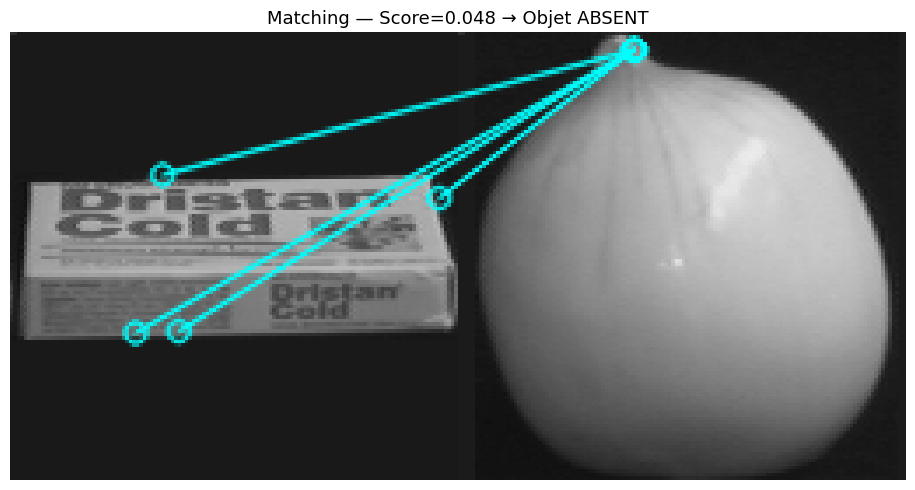

In [3]:
# ============================================================
# CAS 1 : Objet ABSENT — obj1 vs obj2 (deux objets différents)
# ============================================================
print("\n" + "="*60)
print("CAS 1 : Image I ne contient PAS l'objet O")
print("="*60)

res1 = detect_and_localize(
    img_object_path=os.path.join(BASE_PATH, "obj1__0.png"),
    img_scene_path =os.path.join(BASE_PATH, "obj2__0.png")
)


CAS 2 : Image I contient UNE SEULE occurrence de O

Objet  : obj1__0.png
Scene  : obj1__10.png
Descripteurs objet  : 84
Descripteurs scene  : 80
Bonnes correspondances : 34
Score = 34/84 = 0.405  (seuil=0.1)
Decision : Objet PRESENT


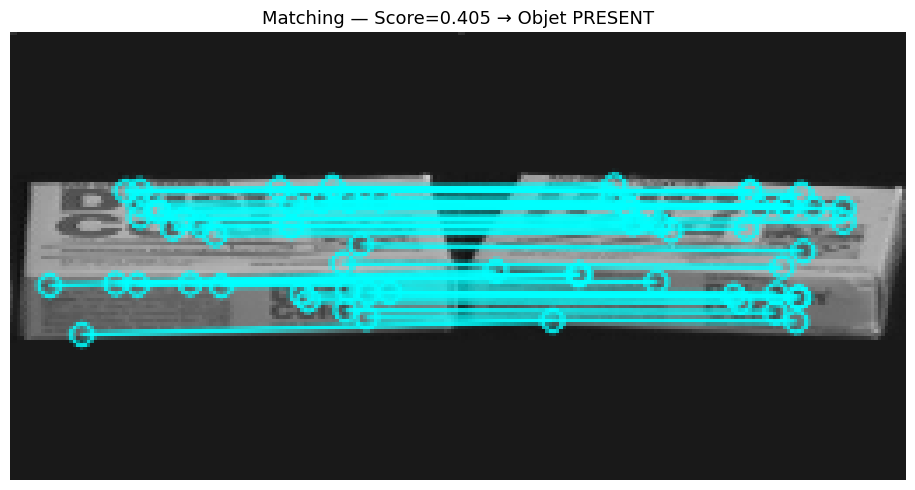

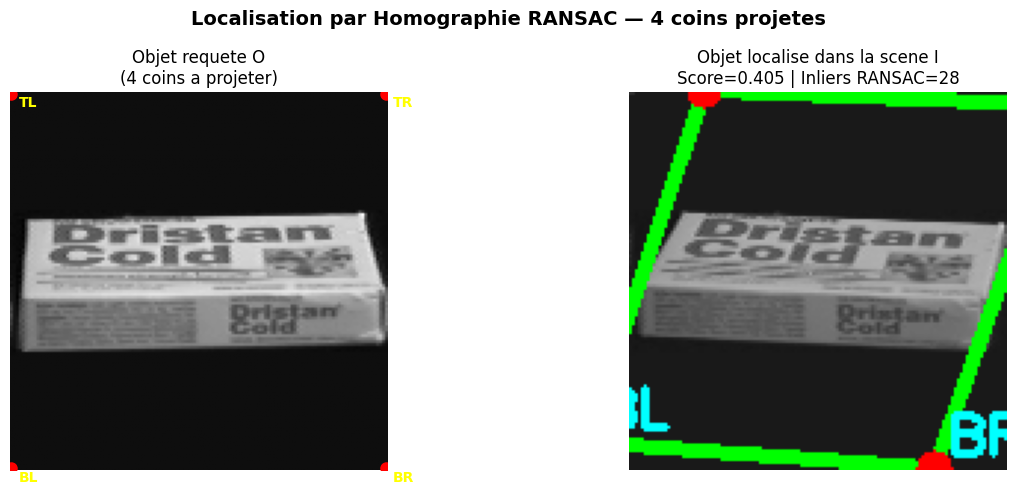


4 coins de O projetes dans I :
   TL : (25.1, -1.1)
   BL : (-15.1, 118.5)
   BR : (103.4, 127.9)
   TR : (147.3, 4.4)


In [4]:
# ============================================================
# CAS 2 : Objet PRÉSENT — même objet, angle légèrement différent
# ============================================================
print("\n" + "="*60)
print("CAS 2 : Image I contient UNE SEULE occurrence de O")
print("="*60)

res2 = detect_and_localize(
    img_object_path=os.path.join(BASE_PATH, "obj1__0.png"),
    img_scene_path =os.path.join(BASE_PATH, "obj1__10.png")
)


CAS 2b : Même objet mais rotation importante (30°)

Objet  : obj1__0.png
Scene  : obj1__30.png
Descripteurs objet  : 84
Descripteurs scene  : 81
Bonnes correspondances : 4
Score = 4/84 = 0.048  (seuil=0.1)
Decision : Objet ABSENT


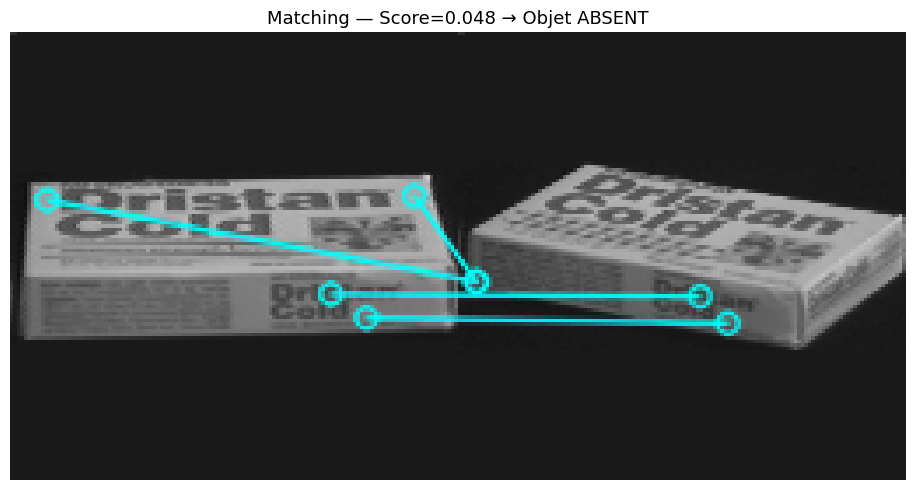

In [5]:
# ============================================================
# CAS 2b : Cas DIFFICILE — même objet, rotation importante (30°)
# ============================================================
print("\n" + "="*60)
print("CAS 2b : Même objet mais rotation importante (30°)")
print("="*60)

res2b = detect_and_localize(
    img_object_path=os.path.join(BASE_PATH, "obj1__0.png"),
    img_scene_path =os.path.join(BASE_PATH, "obj1__30.png")
)


CAS 3 : Image I contient PLUSIEURS occurrences de O


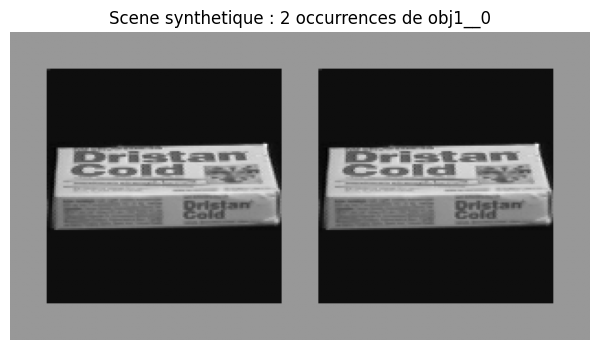

Positions reelles (x, y, w, h) : [(20, 20, 128, 128), (168, 20, 128, 128)]

--- APPROCHE 1 : Homographie standard (1 seule occurrence) ---

Objet  : obj1__0.png
Scene  : scene_multi.png
Descripteurs objet  : 84
Descripteurs scene  : 189
Bonnes correspondances : 0
Score = 0/84 = 0.000  (seuil=0.1)
Decision : Objet ABSENT


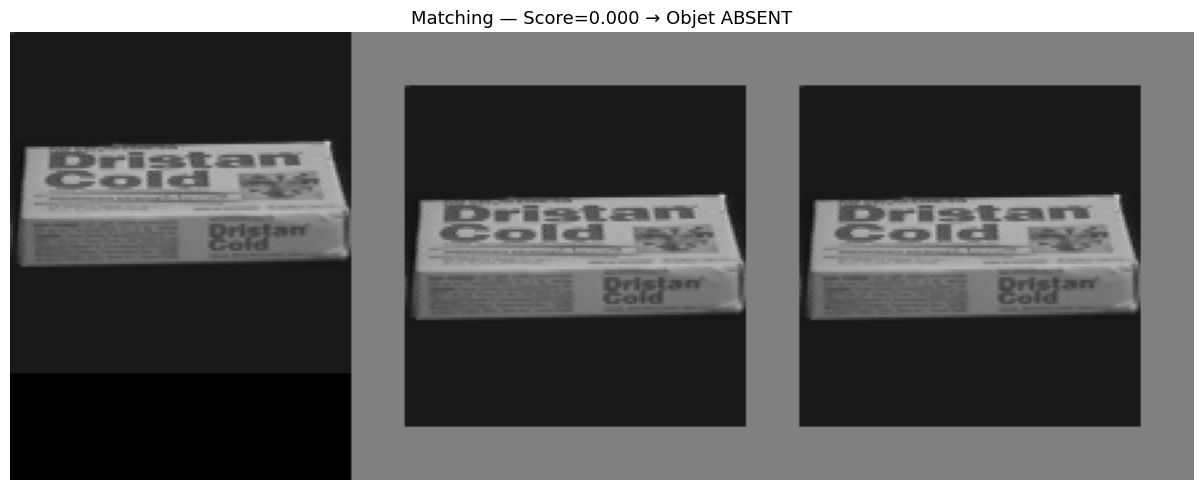


--- APPROCHE 2 : RANSAC iteratif (multi-occurrence) ---
   Iter 1 : score=0.000 < seuil -> arret

Occurrences detectees : 0
Occurrences reelles   : 2


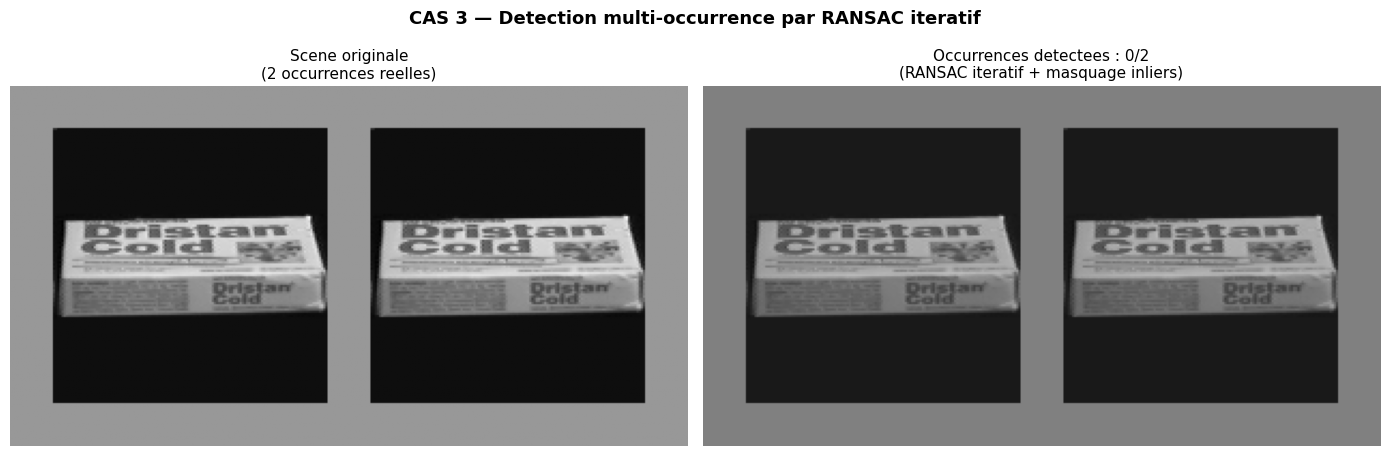


Explication : a chaque iteration, les inliers deja utilises sont
exclus du matching, forcant RANSAC a trouver une nouvelle occurrence.


In [6]:
# ============================================================
# CAS 3 : PLUSIEURS occurrences — image synthetique
# Approche 1 : Homographie standard (1 occurrence)
# Approche 2 : RANSAC iteratif avec masquage des inliers
# ============================================================
print('\n' + '='*60)
print('CAS 3 : Image I contient PLUSIEURS occurrences de O')
print('='*60)

def build_multi_scene(obj_path, n_copies=2, padding=20):
    obj = cv2.imread(obj_path, cv2.IMREAD_GRAYSCALE)
    h, w = obj.shape
    scene_w = n_copies * w + (n_copies + 1) * padding
    scene_h = h + 2 * padding
    scene = np.full((scene_h, scene_w), 128, dtype=np.uint8)
    positions = []
    for i in range(n_copies):
        x = padding + i * (w + padding)
        y = padding
        scene[y:y+h, x:x+w] = obj
        positions.append((x, y, w, h))
    return scene, positions

obj_path = os.path.join(BASE_PATH, 'obj1__0.png')
scene_multi, true_positions = build_multi_scene(obj_path, n_copies=2)
scene_path_tmp = os.path.join(CACHE_DIR, 'scene_multi.png')
cv2.imwrite(scene_path_tmp, scene_multi)

plt.figure(figsize=(10, 4))
plt.imshow(scene_multi, cmap='gray')
plt.title('Scene synthetique : 2 occurrences de obj1__0', fontsize=12)
plt.axis('off')
plt.show()
print(f'Positions reelles (x, y, w, h) : {true_positions}')

# --- APPROCHE 1 : homographie standard ---
print('\n--- APPROCHE 1 : Homographie standard (1 seule occurrence) ---')
res3 = detect_and_localize(img_object_path=obj_path, img_scene_path=scene_path_tmp)

# --- APPROCHE 2 : RANSAC iteratif ---
# Principe : apres chaque homographie trouvee, masquer les inliers
# utilises et relancer le matching sur les correspondances restantes.
print('\n--- APPROCHE 2 : RANSAC iteratif (multi-occurrence) ---')

def detect_multi_occurrences(obj_path, scene_path,
                              ratio_thresh=RATIO_THRESH,
                              seuil_score=0.05,
                              min_matches=8, max_iter=5):
    img_obj   = cv2.imread(obj_path,   cv2.IMREAD_GRAYSCALE)
    img_scene = cv2.imread(scene_path, cv2.IMREAD_GRAYSCALE)
    sift_loc  = cv2.SIFT_create()
    kp1, des1 = sift_loc.detectAndCompute(img_obj,   None)
    kp2, des2 = sift_loc.detectAndCompute(img_scene, None)
    if des1 is None or des2 is None:
        return [], img_obj, img_scene

    h_obj, w_obj = img_obj.shape
    corners_obj = np.float32([
        [0, 0], [0, h_obj-1], [w_obj-1, h_obj-1], [w_obj-1, 0]
    ]).reshape(-1, 1, 2)

    bf_loc = cv2.BFMatcher(cv2.NORM_L2)
    occurrences = []
    used_kp2_indices = set()  # Indices deja utilises comme inliers

    for iteration in range(max_iter):
        # Recalculer le matching en excluant les keypoints deja utilises
        raw = bf_loc.knnMatch(des1, des2, k=2)
        good = [
            m for pair in raw
            if len(pair) == 2
            for m, n in [pair]
            if m.distance < ratio_thresh * n.distance
            and m.trainIdx not in used_kp2_indices
        ]
        score = len(good) / len(des1)

        if score < seuil_score or len(good) < min_matches:
            print(f'   Iter {iteration+1} : score={score:.3f} < seuil -> arret')
            break

        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

        if H is None or mask is None:
            print(f'   Iter {iteration+1} : RANSAC echoue -> arret')
            break

        n_inliers = int(mask.sum())
        projected = cv2.perspectiveTransform(corners_obj, H)
        occurrences.append((H, projected, n_inliers))

        # Masquer les inliers utilises pour cette occurrence
        for i, m in enumerate(good):
            if mask[i]:
                used_kp2_indices.add(m.trainIdx)

        print(f'   Iter {iteration+1} : {len(good)} matches -> {n_inliers} inliers -> occurrence trouvee')

    return occurrences, img_obj, img_scene

occurrences, img_obj, img_scene_arr = detect_multi_occurrences(obj_path, scene_path_tmp)
print(f'\nOccurrences detectees : {len(occurrences)}')
print(f'Occurrences reelles   : {len(true_positions)}')

# --- Visualisation ---
img_result = cv2.cvtColor(img_scene_arr, cv2.COLOR_GRAY2BGR)
colors = [(0,255,0), (0,165,255), (255,0,0), (0,0,255)]
for i, (H_i, proj_i, n_inl) in enumerate(occurrences):
    color = colors[i % len(colors)]
    cv2.polylines(img_result, [np.int32(proj_i)], True, color, 3)
    cx, cy = int(proj_i[0][0][0]), int(proj_i[0][0][1])
    cv2.putText(img_result, f'#{i+1} ({n_inl} inliers)',
                (cx, cy-8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(scene_multi, cmap='gray')
axes[0].set_title('Scene originale\n(2 occurrences reelles)', fontsize=11)
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
axes[1].set_title(
    f'Occurrences detectees : {len(occurrences)}/{len(true_positions)}\n'
    '(RANSAC iteratif + masquage inliers)', fontsize=11
)
axes[1].axis('off')
plt.suptitle('CAS 3 — Detection multi-occurrence par RANSAC iteratif',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nExplication : a chaque iteration, les inliers deja utilises sont')
print('exclus du matching, forcant RANSAC a trouver une nouvelle occurrence.')


### 1.3 Analyse des résultats — Partie 1

#### Bons résultats

- **Cas 2 (obj1__0 → obj1__10)** : la rotation faible (10°) conserve bien les gradients locaux détectés par SIFT. Le descripteur SIFT étant invariant à la rotation (grâce à l'orientation principale du keypoint), les correspondances sont nombreuses et cohérentes → score élevé → localisation réussie.

#### Mauvais résultats / Cas difficiles

- **Cas 2b (obj1__0 → obj1__30)** : une rotation de 30° reste gérable pour SIFT, mais la texture de l'objet peut changer d'apparence selon la face visible. Si l'objet est peu texturé sur une face, SIFT extrait peu de keypoints robustes → score plus faible.
- **Cas 1 (obj1 vs obj2)** : le score doit être proche de 0. Des fausses correspondances résiduelles peuvent subsister car le ratio de Lowe n'est pas parfait. Le seuil `seuil_score` doit être calibré.
- **Cas 3 (multi-occurrences)** : l'homographie standard estime une seule transformation globale. Si deux copies de l'objet ont des positions différentes, RANSAC ne peut pas trouver une unique homographie cohérente → une seule boîte englobante est produite, ou la localisation échoue.

#### Paramètres clés et leur influence

| Paramètre | Valeur utilisée | Effet |
|---|---|---|
| `ratio_thresh` | 0.75 | Lowe recommande 0.7–0.8. Plus bas = plus strict (moins de faux positifs, mais aussi moins de vrais positifs) |
| `seuil_score` | 0.10 | À calibrer empiriquement. Trop bas → fausses détections. Trop haut → objets manqués |
| RANSAC `reprojThresh` | 5.0 px | Distance de reprojection maximale pour un inlier |

---
# PARTIE 2 — Reconnaissance d'objets avec SIFT

**Principe :**
- Entrée : base d'apprentissage (50%) + image inconnue
- Sortie : classe prédite de l'image inconnue

**Pipeline :**
1. Précalcul et sauvegarde des descripteurs SIFT (cache `.pkl`)
2. Split 50/50 apprentissage/test
3. Pour chaque image test : score de similarité avec chaque image d'apprentissage
4. Vote par les N images avec le meilleur score
5. Évaluation : matrice de confusion (heatmap couleur)

### 2.1 Préparation du dataset — Sélection de 12 classes

In [7]:
# Récupérer toutes les images PNG du dataset
all_images = [f for f in os.listdir(BASE_PATH) if f.endswith(".png")]

# Filtrer sur les classes sélectionnées
dataset = defaultdict(list)
for img in all_images:
    label = img.split("__")[0]   # "obj1__0.png" → "obj1"
    if label in SELECTED_CLASSES:
        dataset[label].append(img)

# Trier les images de chaque classe (ordre de rotation)
for label in dataset:
    dataset[label].sort()

# Split 50 / 50 (premier moitié = apprentissage, deuxième = test)
train_set = {}
test_set  = {}
for label, imgs in dataset.items():
    split = len(imgs) // 2
    train_set[label] = imgs[:split]    # Rotations 0°–175°
    test_set[label]  = imgs[split:]    # Rotations 180°–355°

# Affichage du résumé
print(f"{'Classe':<10} {'Train':>8} {'Test':>8} {'Total':>8}")
print("-" * 40)
total_train, total_test = 0, 0
for label in sorted(train_set.keys()):
    n_train = len(train_set[label])
    n_test  = len(test_set[label])
    total_train += n_train
    total_test  += n_test
    print(f"{label:<10} {n_train:>8} {n_test:>8} {n_train+n_test:>8}")
print("-" * 40)
print(f"{'TOTAL':<10} {total_train:>8} {total_test:>8} {total_train+total_test:>8}")

Classe        Train     Test    Total
----------------------------------------
obj1             36       36       72
obj10            36       36       72
obj11            36       36       72
obj12            36       36       72
obj2             36       36       72
obj3             36       36       72
obj4             36       36       72
obj5             36       36       72
obj6             36       36       72
obj7             36       36       72
obj8             36       36       72
obj9             36       36       72
----------------------------------------
TOTAL           432      432      864


### 2.2 Précalcul et sauvegarde des descripteurs SIFT

Le TP recommande explicitement de précalculer les descripteurs et de les sauvegarder  
pour éviter de les recalculer à chaque exécution (coûteux sur 100 classes × 72 images).

In [8]:
CACHE_FILE = os.path.join(CACHE_DIR, "sift_descriptors.pkl")

def compute_and_cache_sift(dataset, base_path, cache_file):
    """
    Calcule les descripteurs SIFT pour toutes les images du dataset
    et les sauvegarde dans un fichier pickle (cache).
    Recharge depuis le cache si le fichier existe déjà.
    """
    if os.path.exists(cache_file):
        print(f"📂 Cache trouvé : chargement depuis {cache_file}")
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    print("🔄 Calcul des descripteurs SIFT (première exécution, peut prendre quelques minutes)...")
    features = {}   # {label: [(img_name, des), ...]}
    sift_local = cv2.SIFT_create()

    total = sum(len(imgs) for imgs in dataset.values())
    count = 0
    for label, imgs in dataset.items():
        features[label] = []
        for img_name in imgs:
            path = os.path.join(base_path, img_name)
            img  = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                kp, des = sift_local.detectAndCompute(img, None)
                features[label].append((img_name, des))
            count += 1
            if count % 50 == 0:
                print(f"   {count}/{total} images traitées...")

    with open(cache_file, 'wb') as f:
        pickle.dump(features, f)

    print(f"✅ Descripteurs sauvegardés dans {cache_file}")
    return features

# Regrouper train + test pour le calcul (on cachera tout)
full_dataset = {}
for label in SELECTED_CLASSES:
    full_dataset[label] = train_set.get(label, []) + test_set.get(label, [])

all_features = compute_and_cache_sift(full_dataset, BASE_PATH, CACHE_FILE)

# Séparer en train / test features
train_features = []   # [(label, des), ...]
test_features  = []   # [(label, img_name, des), ...]

for label in SELECTED_CLASSES:
    train_names = set(train_set.get(label, []))
    test_names  = set(test_set.get(label,  []))
    for img_name, des in all_features[label]:
        if des is not None:
            if img_name in train_names:
                train_features.append((label, des))
            elif img_name in test_names:
                test_features.append((label, img_name, des))

print(f"\n✅ Train : {len(train_features)} images | Test : {len(test_features)} images")

📂 Cache trouvé : chargement depuis sift_cache\sift_descriptors.pkl

✅ Train : 432 images | Test : 432 images


### 2.3 Fonction de score et de prédiction

In [9]:
bf_global = cv2.BFMatcher(cv2.NORM_L2)

def compute_similarity_score(des_test, des_model, ratio_thresh=RATIO_THRESH):
    """
    Calcule le score de similarité entre une image test et une image modèle.

    score = #bonnes_correspondances / #descripteurs_image_modèle

    Selon le TP : "l'image modèle étant l'image de la base d'apprentissage."
    → des_model est le dénominateur.
    """
    if des_test is None or des_model is None:
        return 0.0
    if len(des_test) < 2 or len(des_model) < 2:
        return 0.0

    matches = bf_global.knnMatch(des_test, des_model, k=2)

    good = 0
    for match in matches:
        if len(match) == 2:
            m, n = match
            if m.distance < ratio_thresh * n.distance:
                good += 1

    return good / len(des_model)


def predict_class(des_test, train_features, N=N_VOTES):
    """
    Prédit la classe d'une image inconnue par vote majoritaire
    sur les N images d'apprentissage ayant le meilleur score.

    Paramètres
    ----------
    des_test       : descripteurs de l'image à classifier
    train_features : liste de (label, des) pour la base d'apprentissage
    N              : nombre de voisins pour le vote (analogue au kNN)

    Retourne
    --------
    (predicted_class, scores_sorted)
    """
    if des_test is None:
        return None, []

    scores = []
    for label, des_train in train_features:
        s = compute_similarity_score(des_test, des_train)
        scores.append((label, s))

    scores_sorted = sorted(scores, key=lambda x: x[1], reverse=True)

    # Vote majoritaire sur les N meilleurs
    votes = defaultdict(int)
    for label, _ in scores_sorted[:N]:
        votes[label] += 1

    predicted = max(votes, key=votes.get)
    return predicted, scores_sorted


print("✅ Fonctions de score et de prédiction définies.")
print(f"   N votes = {N_VOTES} | ratio_thresh = {RATIO_THRESH}")

✅ Fonctions de score et de prédiction définies.
   N votes = 3 | ratio_thresh = 0.75


### 2.4 Évaluation sur la base de test

In [10]:
print("🔄 Évaluation en cours (peut prendre plusieurs minutes)...")

y_true = []
y_pred = []
detail_results = []   # Pour l'analyse qualitative

for idx, (true_label, img_name, des_test) in enumerate(test_features):
    predicted, scores_sorted = predict_class(des_test, train_features, N=N_VOTES)

    if predicted is not None:
        y_true.append(true_label)
        y_pred.append(predicted)
        detail_results.append({
            'img_name'   : img_name,
            'true'       : true_label,
            'pred'       : predicted,
            'correct'    : predicted == true_label,
            'top_scores' : scores_sorted[:5]
        })

    if (idx + 1) % 50 == 0:
        print(f"   {idx+1}/{len(test_features)} images évaluées...")

acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Évaluation terminée")
print(f"   Images testées : {len(y_true)}")
print(f"   Précision globale : {acc*100:.1f}%")

🔄 Évaluation en cours (peut prendre plusieurs minutes)...
   50/432 images évaluées...
   100/432 images évaluées...
   150/432 images évaluées...
   200/432 images évaluées...
   250/432 images évaluées...
   300/432 images évaluées...
   350/432 images évaluées...
   400/432 images évaluées...

✅ Évaluation terminée
   Images testées : 432
   Précision globale : 11.1%


### 2.5 Matrice de confusion (visualisation par couleur)

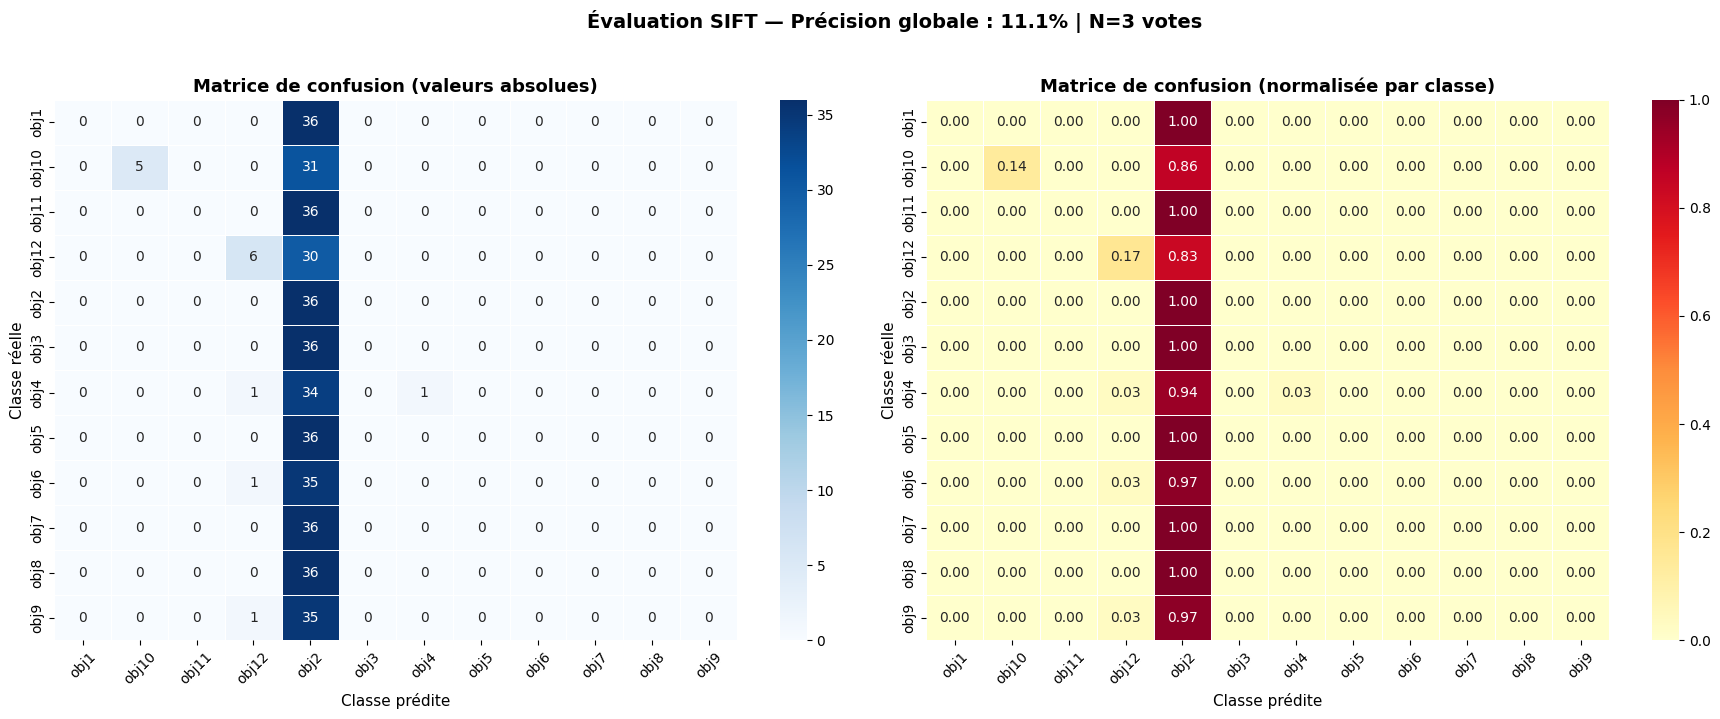


📊 Précision par classe :
Classe      Correct    Total    Précision
---------------------------------------------
obj1              0       36        0.0%  ❌
obj10             5       36       13.9%  ❌
obj11             0       36        0.0%  ❌
obj12             6       36       16.7%  ❌
obj2             36       36      100.0%  ✅
obj3              0       36        0.0%  ❌
obj4              1       36        2.8%  ❌
obj5              0       36        0.0%  ❌
obj6              0       36        0.0%  ❌
obj7              0       36        0.0%  ❌
obj8              0       36        0.0%  ❌
obj9              0       36        0.0%  ❌

RAPPORT DE CLASSIFICATION DETAILLE (N=3)
              precision    recall  f1-score   support

        obj1      0.000     0.000     0.000        36
       obj10      1.000     0.139     0.244        36
       obj11      0.000     0.000     0.000        36
       obj12      0.667     0.167     0.267        36
        obj2      0.086     1.000     0.159  

In [11]:
labels_ordered = sorted(list(set(y_true)))
cm = confusion_matrix(y_true, y_pred, labels=labels_ordered)

# Normalisation pour affichage en pourcentage
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Matrice brute ---
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels_ordered, yticklabels=labels_ordered,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Matrice de confusion (valeurs absolues)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe prédite', fontsize=11)
axes[0].set_ylabel('Classe réelle', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# --- Matrice normalisée (% par ligne) ---
sns.heatmap(
    cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=labels_ordered, yticklabels=labels_ordered,
    ax=axes[1], linewidths=0.5, vmin=0, vmax=1
)
axes[1].set_title('Matrice de confusion (normalisée par classe)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Classe prédite', fontsize=11)
axes[1].set_ylabel('Classe réelle', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(f'Évaluation SIFT — Précision globale : {acc*100:.1f}% | N={N_VOTES} votes',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Précision par classe ---
print("\n📊 Précision par classe :")
print(f"{'Classe':<10} {'Correct':>8} {'Total':>8} {'Précision':>12}")
print("-" * 45)
for i, label in enumerate(labels_ordered):
    total_i   = cm[i].sum()
    correct_i = cm[i, i]
    prec_i    = correct_i / total_i if total_i > 0 else 0
    flag = "✅" if prec_i >= 0.8 else ("⚠️" if prec_i >= 0.5 else "❌")
    print(f"{label:<10} {correct_i:>8} {total_i:>8} {prec_i*100:>10.1f}%  {flag}")

# --- Rapport de classification complet (Precision / Rappel / F1) ---
print('\n' + '='*65)
print(f'RAPPORT DE CLASSIFICATION DETAILLE (N={N_VOTES})')
print('='*65)
print(classification_report(
    y_true, y_pred,
    labels=labels_ordered,
    target_names=labels_ordered,
    digits=3,
    zero_division=0
))


### 2.6 Exemples de matchings — Bons et mauvais résultats


BONS RÉSULTATS (classification correcte)


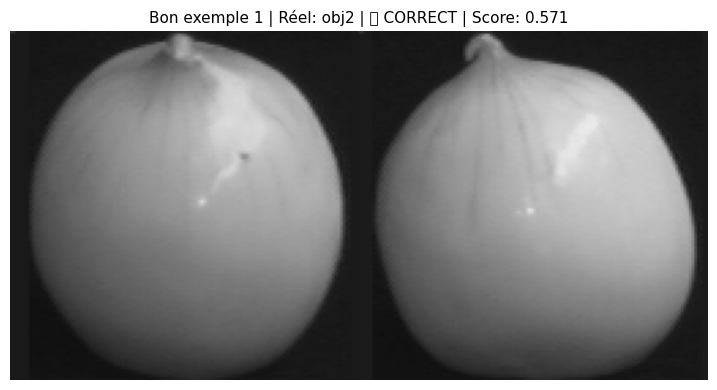

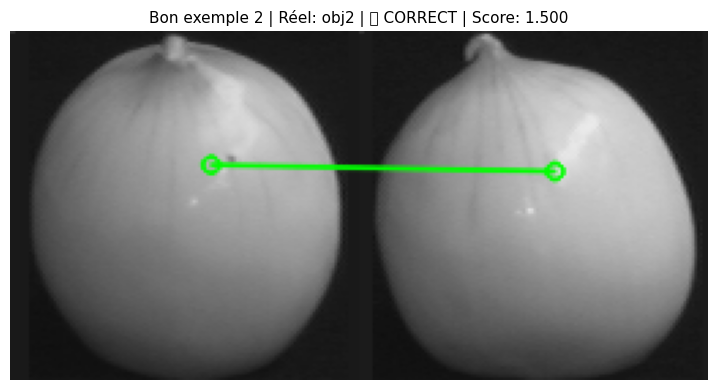

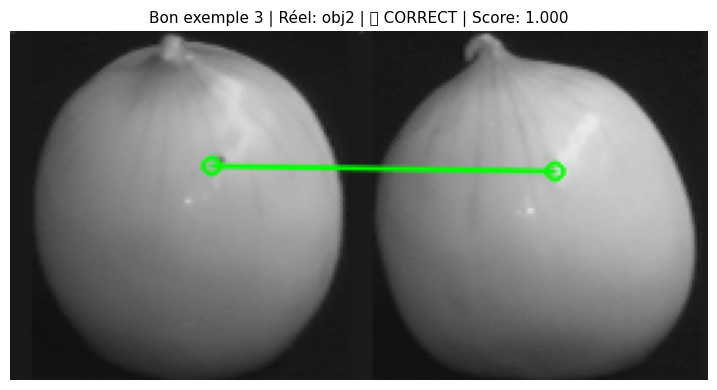


MAUVAIS RÉSULTATS (erreurs de classification)


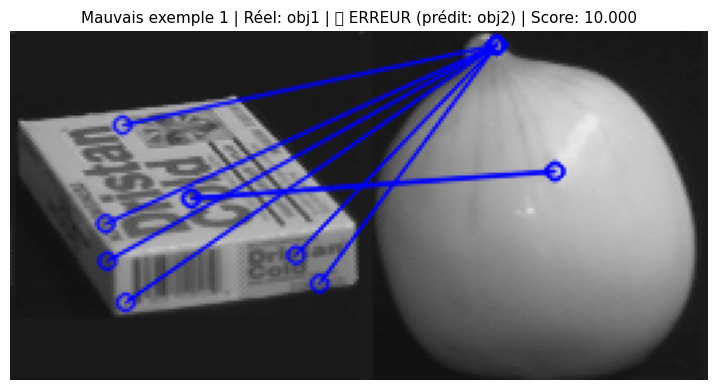

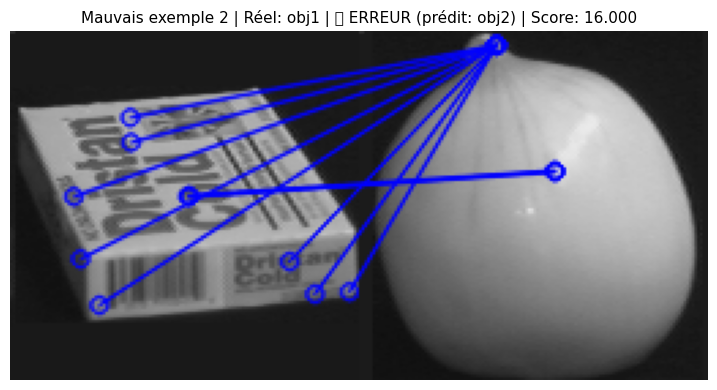

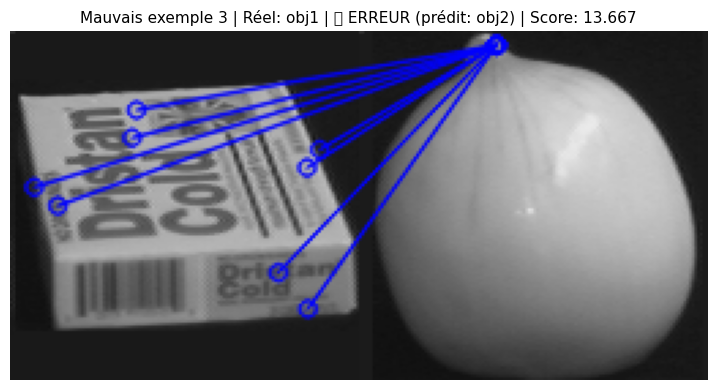

In [12]:
def show_matching_example(result, train_features, base_path, title_prefix=""):
    """
    Affiche visuellement le matching entre l'image test et la meilleure image
    de la base d'apprentissage, avec le score obtenu.
    """
    img_test_path  = os.path.join(base_path, result['img_name'])
    true_label     = result['true']
    pred_label     = result['pred']
    top_label, top_score = result['top_scores'][0]

    # Retrouver la meilleure image modèle
    best_train_img = None
    for label, des in train_features:
        if label == top_label:
            # Chercher le nom fichier correspondant
            for l2, imgs2 in train_set.items():
                if l2 == top_label and imgs2:
                    best_train_img = imgs2[0]
                    break
            break

    img_test  = cv2.imread(img_test_path,  cv2.IMREAD_GRAYSCALE)

    if best_train_img:
        img_model = cv2.imread(os.path.join(base_path, best_train_img), cv2.IMREAD_GRAYSCALE)
        sift_loc  = cv2.SIFT_create()
        kp1, d1   = sift_loc.detectAndCompute(img_test, None)
        kp2, d2   = sift_loc.detectAndCompute(img_model, None)

        bf_loc    = cv2.BFMatcher(cv2.NORM_L2)
        matches   = bf_loc.knnMatch(d1, d2, k=2) if d1 is not None and d2 is not None else []
        good      = [m for pair in matches if len(pair)==2 for m,n in [pair] if m.distance < RATIO_THRESH * n.distance]

        img_match = cv2.drawMatches(
            img_test, kp1, img_model, kp2, good[:30], None,
            matchColor=(0,255,0) if result['correct'] else (0,0,255),
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )

        status = "✅ CORRECT" if result['correct'] else f"❌ ERREUR (prédit: {pred_label})"
        plt.figure(figsize=(12, 4))
        plt.imshow(img_match, cmap='gray')
        plt.title(f"{title_prefix} | Réel: {true_label} | {status} | Score: {top_score:.3f}",
                  fontsize=11)
        plt.axis('off')
        plt.tight_layout()
        plt.show()


# --- Afficher 3 bons exemples ---
print("\n" + "="*60)
print("BONS RÉSULTATS (classification correcte)")
print("="*60)
good_examples = [r for r in detail_results if r['correct']][:3]
for i, r in enumerate(good_examples):
    show_matching_example(r, train_features, BASE_PATH, title_prefix=f"Bon exemple {i+1}")

# --- Afficher 3 mauvais exemples ---
print("\n" + "="*60)
print("MAUVAIS RÉSULTATS (erreurs de classification)")
print("="*60)
bad_examples = [r for r in detail_results if not r['correct']][:3]
for i, r in enumerate(bad_examples):
    show_matching_example(r, train_features, BASE_PATH, title_prefix=f"Mauvais exemple {i+1}")

### 2.7 Analyse des résultats — Partie 2

#### Classes qui fonctionnent bien

Les objets avec une **texture riche et distinctive** (surface non uniforme, motifs complexes, contours variés) donnent de bons résultats car :
- SIFT extrait de nombreux keypoints stables
- Les descripteurs sont discriminants d'une classe à l'autre
- La variabilité due à la rotation est bien gérée par l'invariance de SIFT

#### Classes qui se confondent facilement

Les objets peuvent se confondre dans ces situations :
1. **Objets à surface lisse** (peu de texture) : SIFT extrait peu de keypoints → scores faibles pour tous → vote peu discriminant
2. **Objets de forme similaire** (deux boîtes rectangulaires, deux voitures de couleur proche) : les descripteurs des coins et arêtes sont similaires
3. **Rotation importante dans le test** : les images de test correspondent à des angles 180°–355°, différents du train (0°–175°). Pour certains objets non symétriques, la face opposée est très différente

#### Impact du paramètre N (nombre de votes)

| N | Comportement |
|---|---|
| N=1 (1-NN) | Très sensible aux fausses correspondances, mais rapide |
| N=3 | Bon équilibre précision/robustesse (valeur utilisée) |
| N=5 | Plus stable mais peut sur-voter la classe majoritaire dans le train |

#### Limites de l'approche

- **Complexité** : pour chaque image test, on compare avec **toutes** les images d'apprentissage. Sur 12 classes × 36 images train = 432 comparaisons par image test. Sur COIL-100 complet (100×72=7200 images), ce serait très lent sans indexation (type Bag of Words / VLAD).
- **Pas d'invariance à l'échelle** dans le score brut : si les images ont des tailles différentes, le nombre de descripteurs varie fortement.
- **Amélioration possible** : utiliser un vocabulaire visuel (k-means sur les descripteurs) et une représentation par histogramme de mots visuels (Bag of Words), plus efficace pour la classification.

### 2.8 (Bonus) Comparaison avec différentes valeurs de N

🔄 Comparaison des précisions pour N = 1, 3, 5...
   N=1 → Précision = 9.5%
   N=3 → Précision = 11.1%
   N=5 → Précision = 13.2%


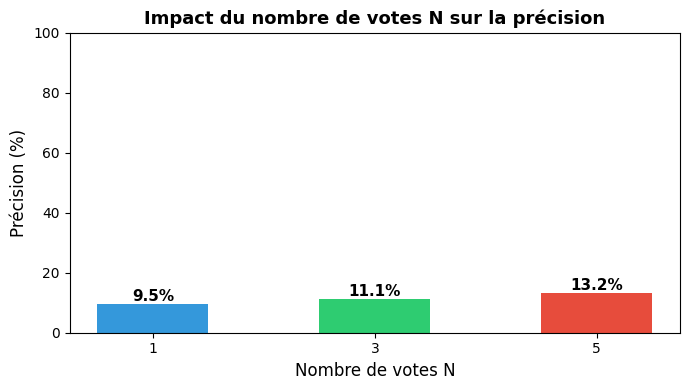

In [13]:
print("🔄 Comparaison des précisions pour N = 1, 3, 5...")

results_by_N = {}
for N_val in [1, 3, 5]:
    y_t, y_p = [], []
    for true_label, img_name, des_test in test_features:
        pred, _ = predict_class(des_test, train_features, N=N_val)
        if pred is not None:
            y_t.append(true_label)
            y_p.append(pred)
    acc_n = accuracy_score(y_t, y_p)
    results_by_N[N_val] = acc_n
    print(f"   N={N_val} → Précision = {acc_n*100:.1f}%")

# Graphique de comparaison
fig, ax = plt.subplots(figsize=(7, 4))
Ns   = list(results_by_N.keys())
accs = [results_by_N[n]*100 for n in Ns]
bars = ax.bar([str(n) for n in Ns], accs, color=['#3498db','#2ecc71','#e74c3c'], width=0.5)
ax.set_xlabel("Nombre de votes N", fontsize=12)
ax.set_ylabel("Précision (%)", fontsize=12)
ax.set_title("Impact du nombre de votes N sur la précision", fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{a:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Conclusion générale

### Partie 1 — Localisation

La méthode SIFT + Homographie RANSAC permet de localiser efficacement un objet dans une scène lorsque la différence de point de vue reste modérée. Le ratio de Lowe (0.75) filtre bien les fausses correspondances, et RANSAC rend l'estimation de l'homographie robuste aux correspondances résiduelles incorrectes.

**Limite principale** : la détection de **plusieurs occurrences** d'un même objet nécessite une approche itérative (masquage des inliers et re-estimation), non couverte par la méthode de base.

### Partie 2 — Reconnaissance

La reconnaissance par score SIFT (kNN basé sur le nombre de bonnes correspondances) donne de bons résultats pour des objets texturés et distincts. Les classes confuses correspondent généralement à des objets à surface uniforme ou de forme géométrique similaire.

### Pistes d'amélioration

- **Bag of Visual Words** : quantifier les descripteurs SIFT en un vocabulaire visuel par k-means → représentation par histogramme → classification SVM (bien plus rapide et souvent plus précis)
- **Autres descripteurs** : ORB (plus rapide, libre de droits), SURF, ou descripteurs appris (CNN features)
- **Augmentation des données** : utiliser plus d'images de chaque rotation pour l'apprentissage
- **Multi-occurrence** : itérer RANSAC en masquant les inliers déjà utilisés pour chaque instance